$$
\begin{array}{c}
\textbf{Linear Regression - Spring 2026}\\\\
\textit{Center for Data Science, New York University} \\\\
\textit{February 6, 2026}\\\\\
\text{ Prepared by: Vivek Kumar Agarwal}\\\\
\textbf{Recitation 2: Linear Regression}
\end{array}
$$

# Simple Linear Regression — Recitation 2
---
We cover today's material in the following steps:
1. **Part 1**: Conditional Distributions 
2. **Part 2**: Conditional Expectations 
3. **Part 3**: Independence & the Law of Iterated Expectations
4. **Part 4**: The Best Linear Approximation to E[Y|X] — A descriptive view of regression
5. **Part 5**: Estimating & Plotting SLR in Python 
6. **Part 6**: SLR on a Noisy DGP 
- Let's code!!

---

## Part 1: Conditional Distributions

- **Joint distributions** characterize the likelihood that a pair of RVs take on a pair of specified values
- **Conditional distributions** tell us the likelihood of one RV taking a value, *given* another RV takes a specified value — probabilities when we "know something"

- **Discrete case:** For $P(X = x_i) > 0$:
$$P(Y = y_j \mid X = x_i) = \frac{P(X = x_i, Y = y_j)}{P(X = x_i)}$$

- **Continuous case:**
$$f(y \mid x) = \frac{f(x, y)}{f(x)}$$

- **Example:** Let $X, Y$ be dice rolls, $Z = X + Y$. Probability of total 12 given $Y = 6$?
$$P(Z = 12 \mid Y = 6) = \frac{P(Z = 12, Y = 6)}{P(Y = 6)} = \frac{1/36}{1/6} = \frac{1}{6}$$

## Part 2: Conditional Expectations

- Conditional distributions allow us to define **conditional expectations** — our "best guess" at the value of one RV given what we know about another

- **Discrete case:** Where $Y$ takes on $k$ values:
$$E[Y \mid X = x_i] = \sum_{j=1}^{k} y_j \, P(Y = y_j \mid X = x_i)$$

- **Continuous case:**
$$E[Y \mid X = x] = \int_{-\infty}^{\infty} y \, f(y \mid x) \, dy$$

- **Key distinction:**
  - $E[Y \mid X]$ is a **function** of the RV $X$ — since $X$ is random, this expression is also random (it takes different values depending on what $X$ turns out to be)
  - $E[Y \mid X = x]$ is evaluated at a specific realization — it is a **fixed number**

- **Example:** Let $Z = X + Y$ (dice rolls). Given $Y = 6$:
$$E[Z \mid Y = 6] = \sum_{z=1}^{12} z \, P(Z = z \mid Y = 6) = (7 + 8 + 9 + 10 + 11 + 12) \cdot \frac{1}{6} = 9.5$$

- Note: 9.5 is not a possible dice outcome — it is the **average** over repeated trials where $Y = 6$
- Until we observe $Y$, $E[Z \mid Y]$ is random — e.g. it equals 9.5 if $Y=6$, but 4.5 if $Y=1$

## Part 3: Independence & the Law of Iterated Expectations

### Independence
- RVs $X$ and $Y$ are **independent** ($X \perp Y$) if for any sets $A, B$:
$$P(X \in A, Y \in B) = P(X \in A) \cdot P(Y \in B)$$

- **Example:** Two distinct dice $X, Y$: $\quad P(X=6, Y=6) = \frac{1}{6} \cdot \frac{1}{6} = \frac{1}{36}$ 


- Under independence, conditioning gives no new information:
  - Discrete: $P(Y = y_j \mid X = x_i) = P(Y = y_j)$
  - Continuous: $f(y \mid x) = f(y)$
  - Conditional expectation: $E[Y \mid X] = E[Y]$, and more generally $E[g(Y) \mid X] = E[g(Y)]$

### Law of Iterated Expectations (LIE)
- For any RVs $X, Y$:
$$E[Y] = E\big[E[Y \mid X]\big]$$

- Here $E[Y \mid X]$ is a **random variable** (a function of $X$). The outer expectation averages over all possible values of $X$:
$$E\big[E[Y \mid X]\big] = \sum_{i} E[Y \mid X = x_i] \cdot P(X = x_i)$$

- **Example:** Average sum of two dice $Z = X + Y$ via LIE:
$$E[Z] = E\big[E[Z \mid Y]\big] = \sum_{y=1}^{6} E[Z \mid Y = y] \cdot P(Y = y) = \frac{1}{6}(4.5 + 5.5 + 6.5 + 7.5 + 8.5 + 9.5) = 7$$

- Recall from Part 2: $E[Z \mid Y=6] = 9.5$ — that was just *one* of the six conditional expectations. The LIE **averages over all of them** to recover the unconditional mean $E[Z] = 7$.

## Part 4: The Best Linear Approximation to $E[Y \mid X]$

- Last recitation we defined $\beta_0, \beta_1$ as the **Best Linear Predictor (BLP)** — minimizing:
$$\min_{b_0, b_1} E[(Y - b_0 - b_1 X)^2]$$

- Now we introduce an equivalent definition — $\beta_0, \beta_1$ as the **best linear approximation to the conditional expectation**:
$$\min_{b_0, b_1} E[(E[Y \mid X] - b_0 - b_1 X)^2]$$

- These two minimization problems yield the **same** $\beta_0, \beta_1$ (proven using the LIE)

- **Why care about two definitions?**
  - BLP → **predictive** interpretation (minimize prediction error)
  - Approximation to $E[Y \mid X]$ → **descriptive** interpretation (understand how the average of $Y$ changes with $X$)

- The residual is the same under both:
$$\varepsilon \equiv Y - \beta_0 - \beta_1 X$$

- And the key properties still hold:
$$E[\varepsilon] = 0, \quad E[X\varepsilon] = 0$$

-  $E[\varepsilon] = 0$ means the regression errors average out
-  $E[X\varepsilon] = 0$ means the errors are uncorrelated with the regressor (no systematic pattern left to exploit)

- **Important:** "Best linear" doesn't mean *good* — if $E[Y \mid X]$ is highly nonlinear, the linear approximation may be poor

---

## Part 5: Estimating & Plotting SLR 

- We will use the **Bike Sharing Dataset** (`day.csv`) — daily bike rental counts alongside weather and seasonal information
- The dataset contains 731 days of data with 16 variables including temperature, humidity, windspeed, and rental counts
- **Our goal:** Use `temp` (normalized temperature) to predict `registered` (number of registered bike rentals)
- We want to estimate the SLR model:
$$\text{registered} = \beta_0 + \beta_1 \cdot \text{temp} + \varepsilon$$
- **Predictive interpretation:** What is the best linear predictor of registered rentals given temperature?
- **Descriptive interpretation:** How does the average number of registered rentals change with temperature?

## Lets code 

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

In [2]:
df = pd.read_csv("../data/day.csv")
df.head()

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     731 non-null    int64  
 1   dteday      731 non-null    object 
 2   season      731 non-null    int64  
 3   yr          731 non-null    int64  
 4   mnth        731 non-null    int64  
 5   holiday     731 non-null    int64  
 6   weekday     731 non-null    int64  
 7   workingday  731 non-null    int64  
 8   weathersit  731 non-null    int64  
 9   temp        731 non-null    float64
 10  atemp       731 non-null    float64
 11  hum         731 non-null    float64
 12  windspeed   731 non-null    float64
 13  casual      731 non-null    int64  
 14  registered  731 non-null    int64  
 15  cnt         731 non-null    int64  
dtypes: float64(4), int64(11), object(1)
memory usage: 91.5+ KB


### We are interested in the relationship between `temp` and `registered` — let's subset and visualize

In [4]:
df = df[['temp', 'registered']]
df.head()

,temp,registered
0,0.344167,654
1,0.363478,670
2,0.196364,1229
3,0.200000,1454
4,0.226957,1518


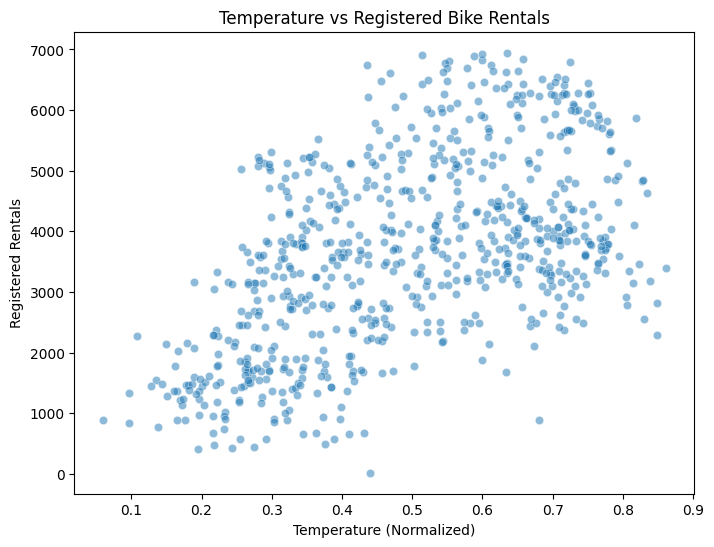

In [5]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x='temp', y='registered', data=df, alpha=0.5)
plt.xlabel("Temperature (Normalized)")
plt.ylabel("Registered Rentals")
plt.title("Temperature vs Registered Bike Rentals")
plt.show()

### Recall from last lecture: Covariance and Correlation measure the linear relationship between two variables

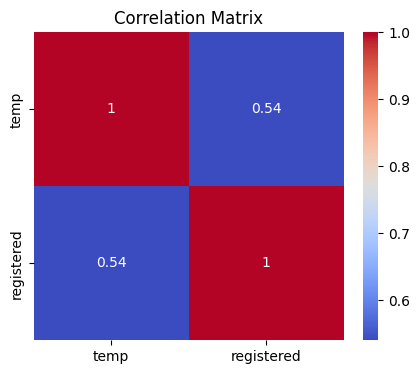

In [6]:
corr_matrix = df.corr()
plt.figure(figsize=(5, 4))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

In [7]:
cov_xy = df['temp'].cov(df['registered'])
var_x = df['temp'].var()
cor_xy = df['temp'].corr(df['registered'])

print(f"Cov(temp, registered) = {cov_xy:.4f}")
print(f"Var(temp)             = {var_x:.4f}")
print(f"Corr(temp, registered)= {cor_xy:.4f}")

Cov(temp, registered) = 154.2309
Var(temp)             = 0.0335
Corr(temp, registered)= 0.5400


### From last lecture, the BLP solution gives us closed-form expressions for $\beta_0$ and $\beta_1$:

$$\beta_1 = \frac{Cov(X, Y)}{Var(X)}$$

$$\beta_0 = E[Y] - \beta_1 \cdot E[X]$$

- $\beta_1$: We already computed $Cov(X,Y)$ and $Var(X)$ — just divide
- $\beta_0$: Uses the fact that the regression line always passes through the point $(\bar{X}, \bar{Y})$
- Let's compute these using our data:

In [8]:
beta_1 = cov_xy / var_x
beta_0 = df['registered'].mean() - beta_1 * df['temp'].mean()

print(f"β1 = Cov(X,Y) / Var(X) = {beta_1:.4f}")
print(f"β0 = E[Y] - β1 * E[X]  = {beta_0:.4f}")

β1 = Cov(X,Y) / Var(X) = 4602.8546
β0 = E[Y] - β1 * E[X]  = 1375.9882


### Interpreting the results
- **Cov(temp, registered) > 0**: Temperature and registered rentals move in the **same direction** — warmer days tend to have more rentals
- **Var(temp)**: Measures the spread of temperature values in our data
- **Corr(temp, registered)**: Standardized version of covariance, bounded between $[-1, 1]$ — tells us the **strength** of the linear relationship
- **$\beta_1 = 4602.85$**: A one-unit increase in normalized temperature is associated with ~4603 more registered rentals on average
- **$\beta_0 = 1375.99$**: When normalized temperature is 0, the model predicts ~1376 registered rentals
- Note: These are the **population-style formulas** from last lecture applied to our data — next we verify using `statsmodels`

### Let's verify our manual computation using `statsmodels` OLS

In [9]:
X = df[['temp']]
y = df['registered']
X = sm.add_constant(X)  # Adds intercept column
X.head()

,const,temp
0,1.0,0.344167
1,1.0,0.363478
2,1.0,0.196364
3,1.0,0.200000
4,1.0,0.226957


In [10]:
model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:             registered   R-squared:                       0.292
Model:                            OLS   Adj. R-squared:                  0.291
Method:                 Least Squares   F-statistic:                     300.1
Date:                Thu, 05 Feb 2026   Prob (F-statistic):           1.45e-56
Time:                        20:43:39   Log-Likelihood:                -6285.5
No. Observations:                 731   AIC:                         1.257e+04
Df Residuals:                     729   BIC:                         1.258e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       1375.9882    140.312      9.807      0.0

### Reading the OLS Summary — What matters right now

- **coef**: Our estimated coefficients
  - `const` = $\hat{\beta}_0 = 1375.99$ — predicted registered rentals when temp = 0
  - `temp` = $\hat{\beta}_1 = 4602.85$ — a one-unit increase in temp is associated with ~4603 more rentals

- **R-squared = 0.292**: Temperature alone explains about 29.2% of the variation in registered rentals

- **std err**: Standard error of each coefficient — measures uncertainty in our estimates (more on this later in the course)

- **t and P>|t|**: Test whether each coefficient is significantly different from zero — both p-values are essentially 0, so both coefficients are statistically significant

- Don't worry about the rest of the table for now — we will revisit them later in the course

In [11]:
print(f"Manual:      β0 = {beta_0:.4f}, β1 = {beta_1:.4f}")
print(f"Statsmodels: β0 = {model.params['const']:.4f}, β1 = {model.params['temp']:.4f}")

Manual:      β0 = 1375.9882, β1 = 4602.8546
Statsmodels: β0 = 1375.9882, β1 = 4602.8546


### Plot the regression line on top of the scatter plot

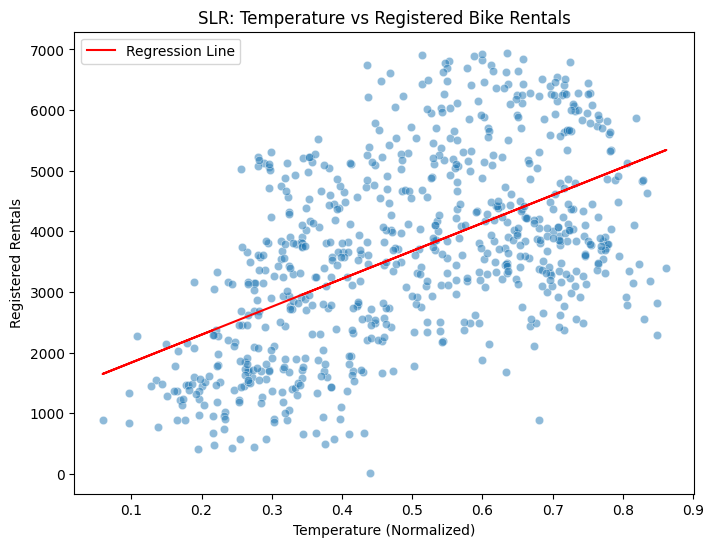

In [12]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x='temp', y='registered', data=df, alpha=0.5)
plt.plot(df['temp'], model.predict(X), color='red', label='Regression Line')
plt.xlabel("Temperature (Normalized)")
plt.ylabel("Registered Rentals")
plt.title("SLR: Temperature vs Registered Bike Rentals")
plt.legend()
plt.show()

### Residual Analysis — Understanding what's left over
- Recall: $\varepsilon_i = y_i - \hat{\beta}_0 - \hat{\beta}_1 x_i$ — the part of $Y$ our model fails to explain
- From theory: $E[\varepsilon] = 0$ and $E[X\varepsilon] = 0$ — let's verify both

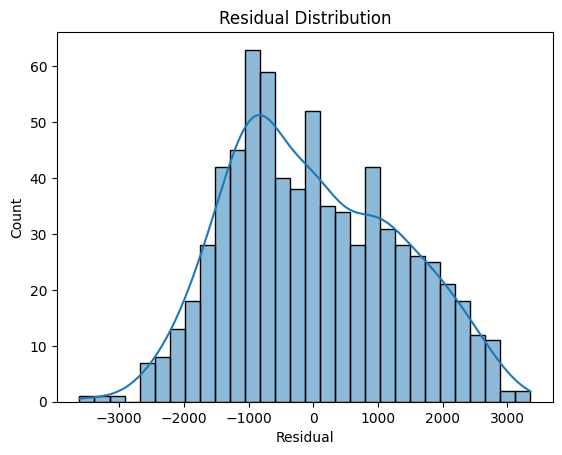

In [13]:
residuals = model.resid
sns.histplot(residuals, bins=30, kde=True)
plt.title("Residual Distribution")
plt.xlabel("Residual")
plt.show()

In [14]:
print(f"Sum of residuals:          {residuals.sum():.6f}")
print(f"Mean of residuals:         {residuals.mean():.6f}")
print(f"Corr(temp, residuals):     {np.corrcoef(df['temp'], residuals)[0,1]:.6f}")

Sum of residuals:          0.000000
Mean of residuals:         0.000000
Corr(temp, residuals):     0.000000


### As expected:
- Residuals have mean ≈ 0 → confirms $E[\varepsilon] = 0$
- Residuals are uncorrelated with `temp` → confirms $E[X\varepsilon] = 0$
- These aren't coincidences — they are **properties** of OLS

---

## Part 6: SLR on a Noisy DGP — Seeing the regression line approximate the true $E[Y \mid X]$

- From lecture: suppose the true data generating process for bike rentals $N$ given temperature $T$ is:
$$N = 300 - T^2 + \gamma, \quad \gamma \sim \text{Unif}[-200, 200], \quad \gamma \perp T$$
- The conditional expectation function (CEF) is:
$$E[N \mid T] = 300 - T^2$$
- This is **nonlinear** — so the SLR line is the best linear *approximation* to this curve
- Let's simulate data from this DGP and compare the SLR line to the true CEF

In [15]:
np.random.seed(42)
T = np.random.uniform(-10, 10, 1000)
gamma = np.random.uniform(-200, 200, 1000)
N = 300 - T**2 + gamma

In [16]:
T_with_const = sm.add_constant(T)
model_sim = sm.OLS(N, T_with_const).fit()
print(model_sim.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.001
Model:                            OLS   Adj. R-squared:                  0.000
Method:                 Least Squares   F-statistic:                     1.323
Date:                Thu, 05 Feb 2026   Prob (F-statistic):              0.250
Time:                        21:01:24   Log-Likelihood:                -6208.1
No. Observations:                1000   AIC:                         1.242e+04
Df Residuals:                     998   BIC:                         1.243e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        268.8115      3.807     70.608      0.0

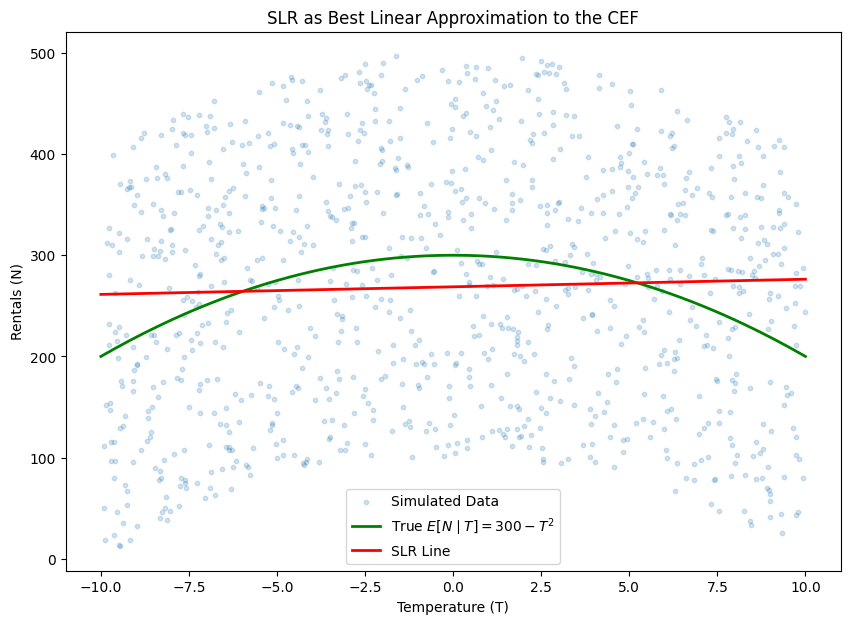

In [17]:
T_grid = np.linspace(-10, 10, 200)
CEF = 300 - T_grid**2

plt.figure(figsize=(10, 7))
plt.scatter(T, N, alpha=0.2, s=10, label='Simulated Data')
plt.plot(T_grid, CEF, color='green', linewidth=2, label=r'True $E[N \mid T] = 300 - T^2$')
plt.plot(T_grid, model_sim.params[0] + model_sim.params[1] * T_grid, color='red', linewidth=2, label='SLR Line')
plt.xlabel("Temperature (T)")
plt.ylabel("Rentals (N)")
plt.title("SLR as Best Linear Approximation to the CEF")
plt.legend()
plt.show()

### Key Takeaway
- The data is noisy, but the **CEF** $E[N \mid T] = 300 - T^2$ is a clean curve
- The **SLR line** is the best linear approximation to that curve — not perfect, but the best a straight line can do
- This is the **descriptive interpretation** from Part 4 in action
- "Best linear" does not mean "good" — the nonlinearity means a lot is left unexplained

### Verifying the BLP closed-form on simulated data
- Same formulas from Part 5 — the BLP and the best linear approximation to $E[Y \mid X]$ give the **same** $\beta_0, \beta_1$

In [18]:
cov_TN = np.cov(T, N)[0, 1]
var_T = np.var(T, ddof=1)

beta_1_manual = cov_TN / var_T
beta_0_manual = np.mean(N) - beta_1_manual * np.mean(T)

print(f"BLP closed-form:  β0 = {beta_0_manual:.4f}, β1 = {beta_1_manual:.4f}")
print(f"Statsmodels OLS:  β0 = {model_sim.params[0]:.4f}, β1 = {model_sim.params[1]:.4f}")

BLP closed-form:  β0 = 268.8115, β1 = 0.7495
Statsmodels OLS:  β0 = 268.8115, β1 = 0.7495


### Can we do better? Fitting a nonlinear model using statsmodels
- The true CEF is $E[N \mid T] = 300 - T^2$ — a quadratic, not a line
- We can add $T^2$ as a regressor — the model is still **linear in parameters**:
$$N = \beta_0 + \beta_1 T + \beta_2 T^2 + \varepsilon$$

In [19]:
T_df = pd.DataFrame({'T': T, 'T_sq': T**2})
T_df = sm.add_constant(T_df)
model_quad = sm.OLS(N, T_df).fit()
print(model_quad.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.058
Model:                            OLS   Adj. R-squared:                  0.056
Method:                 Least Squares   F-statistic:                     30.55
Date:                Thu, 05 Feb 2026   Prob (F-statistic):           1.33e-13
Time:                        21:12:45   Log-Likelihood:                -6179.1
No. Observations:                1000   AIC:                         1.236e+04
Df Residuals:                     997   BIC:                         1.238e+04
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        301.3879      5.610     53.727      0.0

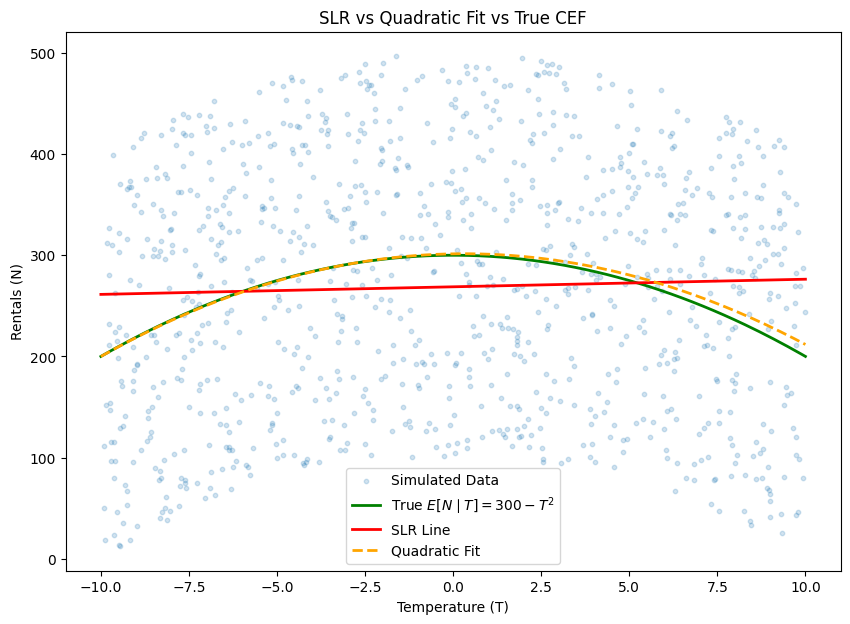

In [20]:
plt.figure(figsize=(10, 7))
plt.scatter(T, N, alpha=0.2, s=10, label='Simulated Data')
plt.plot(T_grid, CEF, color='green', linewidth=2, label=r'True $E[N \mid T] = 300 - T^2$')
plt.plot(T_grid, model_sim.params[0] + model_sim.params[1] * T_grid, color='red', linewidth=2, label='SLR Line')
plt.plot(T_grid, model_quad.params[0] + model_quad.params[1] * T_grid + model_quad.params[2] * T_grid**2, 
         color='orange', linewidth=2, linestyle='--', label='Quadratic Fit')
plt.xlabel("Temperature (T)")
plt.ylabel("Rentals (N)")
plt.title("SLR vs Quadratic Fit vs True CEF")
plt.legend()
plt.show()

### Observation
- The quadratic fit nearly perfectly recovers the true CEF $E[N \mid T] = 300 - T^2$
- Check the coefficients: $\hat{\beta}_0 \approx 300$, $\hat{\beta}_1 \approx 0$, $\hat{\beta}_2 \approx -1$ — matches the DGP!
- The model is still "linear regression" — linear in **parameters**, even though nonlinear in $T$

---

## Office Hours Friday 11 AM - 1 PM  Room No - 244
or dropin your questions at vka244@nyu.edu

---